In [ ]:
import numpy as np
import nibabel as nb
from scipy.optimize import curve_fit

In [ ]:
img = nb.load("/Users/ayush/Desktop/project-internsip/new_work/OneDrive_2_23-05-2025/Simulation-III_Nifty-data/Simulation-III_SNR15/Data-1_Simulation-III_SNR-15.nii")
data = img.get_fdata()  # shape: (X, Y, Z, N)
b_values = np.array([0, 50, 100, 200, 400, 800])

IndentationError: expected an indented block (3887319200.py, line 6)

In [ ]:
shape = data.shape[:3]
f_map = np.zeros(shape)
Dstar_map = np.zeros(shape)
D_map = np.zeros(shape)
AIC_map = np.zeros(shape)

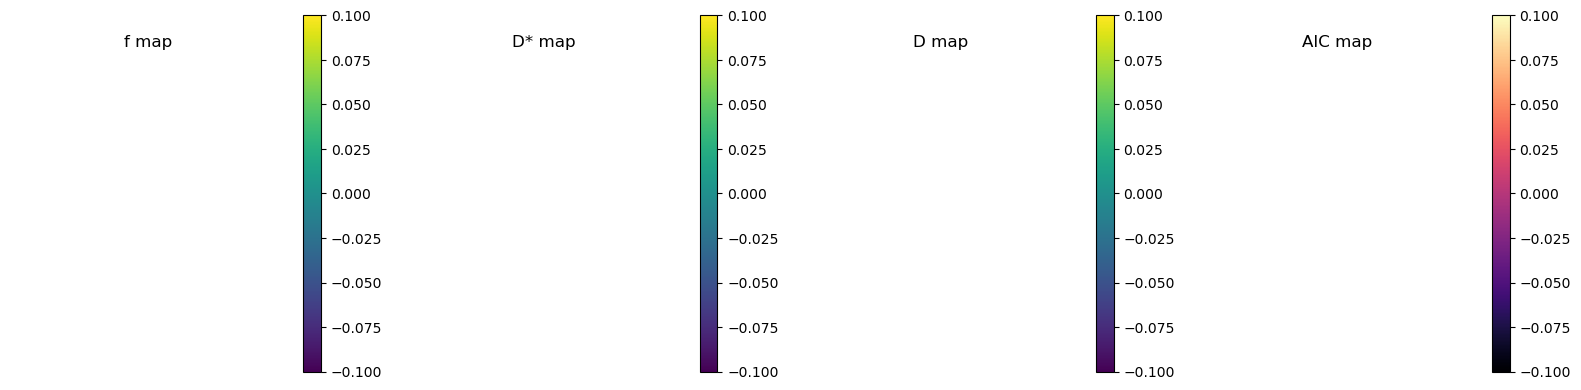

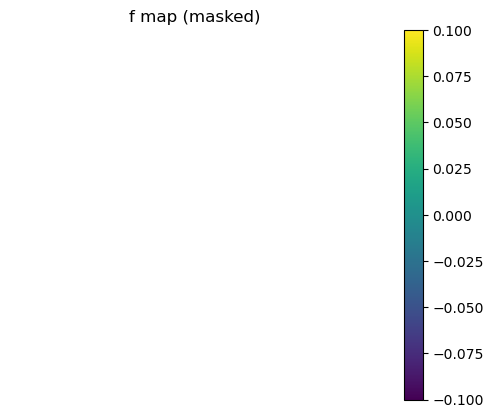

In [ ]:
def ivim(b, f, Dstar, D):
    return f * np.exp(-b * Dstar) + (1 - f) * np.exp(-b * D)

for x in range(shape[0]):
    for y in range(shape[1]):
        for z in range(shape[2]):
            s = data[x, y, z, :]
            if s[0] > 10:  # Only fit if b=0 signal is above threshold
                y_data = s / s[0]  # S/S0
                try:
                    popt, _ = curve_fit(ivim, b_values, y_data, bounds=([0,0,0],[1,0.1,0.01]))
                    residuals = y_data - ivim(b_values, *popt)
                    rss = np.sum(residuals**2)
                    k = len(popt)
                    n = len(y_data)
                    aic = 2 * k + n * np.log(rss / n)
                    f_map[x, y, z] = popt[0]
                    Dstar_map[x, y, z] = popt[1]
                    D_map[x, y, z] = popt[2]
                    AIC_map[x, y, z] = aic
                except:
                    f_map[x, y, z] = np.nan
                    Dstar_map[x, y, z] = np.nan
                    D_map[x, y, z] = np.nan
                    AIC_map[x, y, z] = np.nan
            else:
                f_map[x, y, z] = np.nan
                Dstar_map[x, y, z] = np.nan
                D_map[x, y, z] = np.nan
                AIC_map[x, y, z] = np.nan